### 🤖 Implement ReAct with LangGraph-What is ReAct?
ReAct (Reasoning + Acting) is a framework where an LLM:

- Reasons step-by-step (e.g. decomposes questions, makes decisions)

- Acts by calling tools like search, calculators, or retrievers

This makes it perfect for Agentic RAG:
✅ Think → Retrieve → Observe → Reflect → Final Answer

In [2]:
import os
import wikipedia
from typing import Annotated, Sequence, TypedDict

from dotenv import load_dotenv
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.vectorstores import FAISS
from langchain_core.messages import BaseMessage, HumanMessage

from langchain_core.tools import Tool
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, StateGraph

from langgraph.graph.message import add_messages
from langgraph.prebuilt import create_react_agent

In [3]:
## 1. Create Retriever Tool

## Load content from blog
docs = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/").load()
splitter = RecursiveCharacterTextSplitter(chunk_size = 500, chunk_overlap = 50)
chunks = splitter.split_documents(docs)

# embedding = OpenAIEmbeddings()
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vectorstore = FAISS.from_documents(chunks, embeddings)
retriever = vectorstore.as_retriever()

retriever.invoke("what are autonomous agents")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[Document(id='5b8433bc-02a5-4f54-aaa4-f6236c0c38a8', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

In [4]:
## Create a tool function
from langchain_core.tools import tool

@tool
def rag_retriever_tool(query: str) -> str:
    """Useful for fetching relevant knowledge base information about autonomous AI agents."""
    print("📚 Using RAGRetriever tool")
    fetched_docs = retriever.invoke(query)
    return "\n\n".join([doc.page_content for doc in fetched_docs])

# Assign it directly to your tool list
rag_tool = rag_retriever_tool

In [5]:
## Create the wikipedia tool
wiki_tool = WikipediaQueryRun(api_wrapper = WikipediaAPIWrapper())
wiki_tool

WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'd:\\Udemy Material\\4-Retrieval-Augmented-Generation\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000))

In [6]:
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

## Initiate the LLM
llm = init_chat_model(model="openai/gpt-oss-120b", model_provider="groq")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.1'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000188FB090440>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000188FB0917F0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

C:\Users\dhruv\AppData\Local\Temp\ipykernel_28764\196084087.py:5: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_node = create_react_agent(llm, tools)


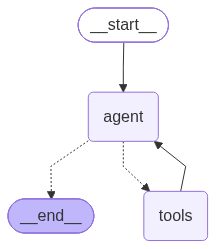

In [7]:
## 2. Define the Agent Node
tools = [rag_tool, wiki_tool]

## Create the native Langgraph react agent
react_node = create_react_agent(llm, tools)
react_node

In [8]:
## 3. LangGraph Agent State
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

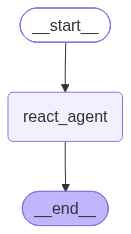

In [9]:
## 4. Build LangGraph Graph
builder = StateGraph(AgentState)

builder.add_node("react_agent", react_node)
builder.set_entry_point("react_agent")
builder.add_edge("react_agent", END)

graph = builder.compile()
graph

In [10]:
## 5. Execute the agent
inputs = {"messages": [HumanMessage(content="What are autonomous agents according to the blog?")]}
response = graph.invoke(inputs)

# Output the final AI response
print(response["messages"][-1].content)

📚 Using RAGRetriever tool
📚 Using RAGRetriever tool
📚 Using RAGRetriever tool
📚 Using RAGRetriever tool
📚 Using RAGRetriever tool
📚 Using RAGRetriever tool
📚 Using RAGRetriever tool
📚 Using RAGRetriever tool
📚 Using RAGRetriever tool
📚 Using RAGRetriever tool
📚 Using RAGRetriever tool
📚 Using RAGRetriever tool
📚 Using RAGRetriever tool
📚 Using RAGRetriever tool
📚 Using RAGRetriever tool
**Autonomous agents (as described in the Lil’Log blog “LLM‑Powered Autonomous Agents”) are software systems whose “brain” is a large language model (LLM) that can act on its own to solve open‑ended tasks.**  

In the blog the author frames an autonomous agent as a **LLM‑controlled controller that is augmented with a small set of complementary components**:

| Component | What it does for the agent |
|-----------|----------------------------|
| **Planning** | The LLM generates and updates a high‑level plan, decomposes tasks, and can self‑reflect on its progress. |
| **Memory** | External storage (e.g., v

### Tool creation for RAG agents with langgraph 
To create tools for RAG agents using LangGraph, you're essentially building LLM-invocable functions that your agent can call as part of its reasoning + acting loop (ReAct).

LangGraph uses the Tool abstraction from LangChain and fully supports tools for:

- RAG retrieval
- Search
- Wikipedia
- SQL
- Web APIs
- Calculators, etc.

#### ✅ Tool Design Requirements
A LangGraph tool must:

- Have a name
- Have a description (used by the LLM to decide when to use it)
- Have a callable func, accepting a single input (usually str) and returning str

In [ ]:
import uuid
from langchain_community.document_loaders import WebBaseLoader, ArxivLoader, TextLoader

## Generic function to create a retireval tool
def make_retriever_tool_from_text(file,name,desc):
    
    ## Load the document and perform operations
    docs = TextLoader(file,encoding="utf-8").load()
    splitter = RecursiveCharacterTextSplitter(chunk_size = 500, chunk_overlap = 50)
    chunks = splitter.split_documents(docs)
    
    vs = FAISS.from_documents(chunks, embeddings)
    retriever = vs.as_retriever()

    def tool_func(query:str)->str:
        
        print(f"📚 Using tool: {name}")
        results = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in results)
    
    return Tool(name = name,description = desc, func = tool_func)

wiki_run = WikipediaQueryRun(api_wrapper = WikipediaAPIWrapper())

## Wikipedia Tool
wiki_tool = Tool(
    name = "Wikipedia",
    description = "Use this tool to fetch general world knowledge from Wikipedia.",
    func = wiki_run.run
)

## ArXiv Tool
def arxiv_search(query: str) -> str:
    print("🧪 Searching ArXiv...")
    results = ArxivLoader(query).load()
    
    return "\n\n".join(doc.page_content[:1000] for doc in results[:2]) or "No papers found."

arxiv_tool = Tool(
    name="ArxivSearch",
    description="Use this tool to fetch recent academic papers on technical topics.",
    func = arxiv_search
)

In [12]:
## Create the internal tools
internal_tool_1 = make_retriever_tool_from_text(
    "sample_docs.txt",
    "InternalTechDocs",
    "Search internal tech documents for proprietary architecture and methods."
)

internal_tool_1

Tool(name='InternalTechDocs', description='Search internal tech documents for proprietary architecture and methods.', func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x00000188EE8872E0>)

In [13]:
internal_tool_2 = make_retriever_tool_from_text(
    "research_notes.txt",
    "InternalResearchNotes",
    "Search internal research notes for experimental results and agent designs."
)

internal_tool_2

Tool(name='InternalResearchNotes', description='Search internal research notes for experimental results and agent designs.', func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x00000188F1532200>)

In [ ]:
import uuid

## Create tools list and then react agent
tools = [wiki_tool, arxiv_tool, internal_tool_1, internal_tool_2]

react_node = create_react_agent(llm, tools)
react_node

In [24]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

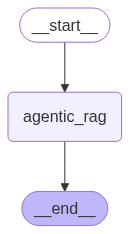

In [25]:
builder = StateGraph(AgentState)
builder.add_node("agentic_rag", react_node)
builder.set_entry_point("agentic_rag")
builder.add_edge("agentic_rag", END)

graph = builder.compile()
graph


In [27]:
query = "What do our internal research notes say about transformer variants, and what does ArXiv suggest recently?"

state = {"messages": [HumanMessage(content=query)]}
result = graph.invoke(state)

print("\n✅ Final Answer:\n", result["messages"][-1].content)

📚 Using tool: InternalResearchNotes
🧪 Searching ArXiv...

✅ Final Answer:
 Our internal research notes highlight a variety of transformer variants evaluated for specific applications:

1. **EfficientFormer**: Achieved a 92.4% top-1 accuracy on TinyImageNet, efficient in quantized int8 mode, intended for deployment on Raspberry Pi 4.

2. **Longformer**: Evaluated on customer support logs and noted for chunk-based hybrid attention to reduce latency during streaming.

3. **Reformer**: Encountered issues with bucket collisions and sparse gradient updates, addressed through gradient clipping and memory-efficient attention modules.

4. **TinyBERT**: Used for classifying support ticket priorities, achieving an 87% F1 score, with successful domain transfer using a 2-layer FFN adapter.

5. **Additional Experiments**:
   - **FlashAttention2**: Integrated into LLaMA2 for reduced latency.
   - **Chain-of-Thought prompting**: Improved performance on logic tasks.
   - **Retrieval Experiments**: Eval